In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from arch import arch_model

In [2]:
df = pd.read_csv('01012015_23022026.csv')
df.head()

,Date,Price,Open,High,Low,Vol.,Change %
0,23-02-2026,"25,625.60","25,678.40","25,769.60","25,610.20",228.23M,0.21%
1,20-02-2026,"25,571.25","25,406.55","25,663.55","25,379.75",296.58M,0.46%
2,19-02-2026,"25,454.35","25,873.35","25,885.30","25,388.75",298.23M,-1.41%
3,18-02-2026,"25,819.35","25,752.65","25,828.05","25,645.15",310.23M,0.37%
4,17-02-2026,"25,725.40","25,637.95","25,764.40","25,570.30",344.12M,0.17%


In [3]:
df.dtypes

Date        object
Price       object
Open        object
High        object
Low         object
Vol.        object
Change %    object
dtype: object

In [4]:
df['Price'] = df['Price'].str.replace(',', '').astype(float)

df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')

df = df.sort_values('Date').reset_index(drop = True)

In [5]:
df.head()

,Date,Price,Open,High,Low,Vol.,Change %
0,2015-01-01,8284.00,"8,272.80","8,294.70","8,248.75",56.56M,0.02%
1,2015-01-02,8395.45,"8,288.70","8,410.60","8,288.70",101.89M,1.35%
2,2015-01-05,8378.40,"8,407.95","8,445.60","8,363.90",118.16M,-0.20%
3,2015-01-06,8127.35,"8,325.30","8,327.85","8,111.35",172.80M,-3.00%
4,2015-01-07,8102.10,"8,118.65","8,151.20","8,065.45",164.08M,-0.31%


In [6]:
df.dtypes

Date        datetime64[ns]
Price              float64
Open                object
High                object
Low                 object
Vol.                object
Change %            object
dtype: object

In [7]:
df['log_returns'] = np.log(df['Price'] / df['Price'].shift(1))

df = df.dropna().reset_index(drop=True)

In [8]:
print(df[['Date', 'Price', 'log_returns']].head())
print(f"\nTotal observations: {len(df)}")
print(f"\nMean return: {df['log_returns'].mean():.6f}")
print(f"Std of returns: {df['log_returns'].std():.6f}")

        Date    Price  log_returns
0 2015-01-02  8395.45     0.013364
1 2015-01-05  8378.40    -0.002033
2 2015-01-06  8127.35    -0.030422
3 2015-01-07  8102.10    -0.003112
4 2015-01-08  8234.60     0.016222

Total observations: 2758

Mean return: 0.000405
Std of returns: 0.010248


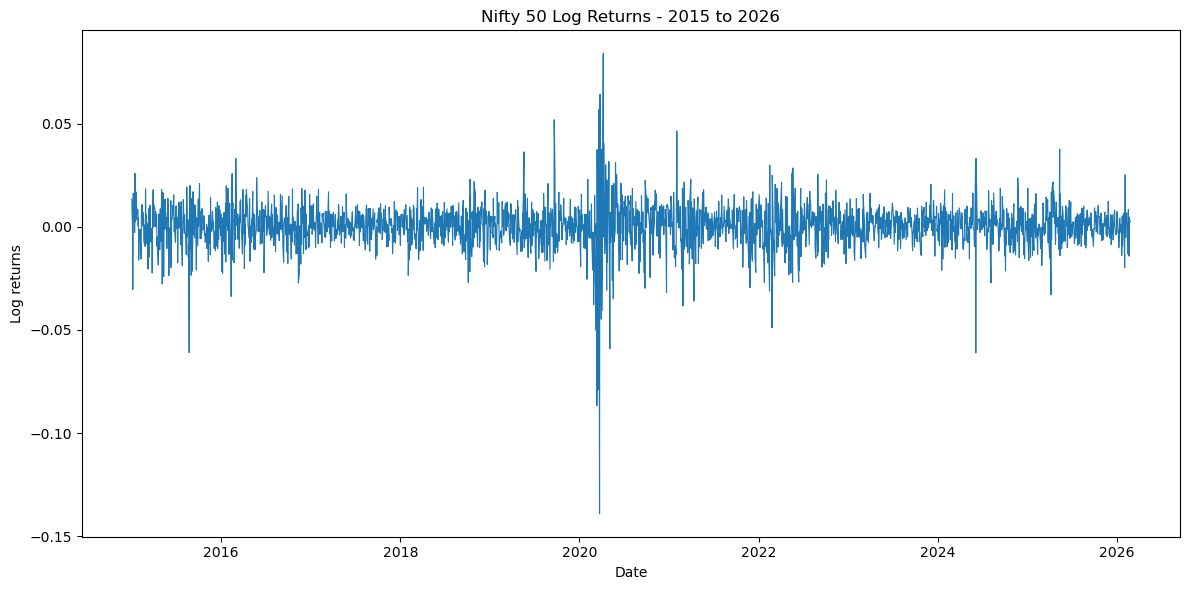

In [9]:
plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['log_returns'], linewidth = 0.8)
plt.title('Nifty 50 Log Returns - 2015 to 2026')
plt.xlabel('Date')
plt.ylabel('Log returns')
plt.tight_layout()
plt.show()

In [10]:
returns = df['log_returns'] * 100
returns

0       1.336395
1      -0.203293
2      -3.042205
3      -0.311163
4       1.622150
          ...   
2753    0.165927
2754    0.364538
2755   -1.423756
2756    0.458202
2757    0.212318
Name: log_returns, Length: 2758, dtype: float64

# Model 1: EGARCH

In [11]:
model = arch_model(returns, mean='constant', vol = 'EGARCH',
                    p=1, o=1, q=1, dist='normal' )

result = model.fit(disp='off')
print(result.summary())

                     Constant Mean - EGARCH Model Results                     
Dep. Variable:            log_returns   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                     EGARCH   Log-Likelihood:               -3484.41
Distribution:                  Normal   AIC:                           6978.81
Method:            Maximum Likelihood   BIC:                           7008.42
                                        No. Observations:                 2758
Date:                Mon, Feb 23 2026   Df Residuals:                     2757
Time:                        18:58:47   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu             0.0337  1.605e-02      2.099  3.584e-02 [2.

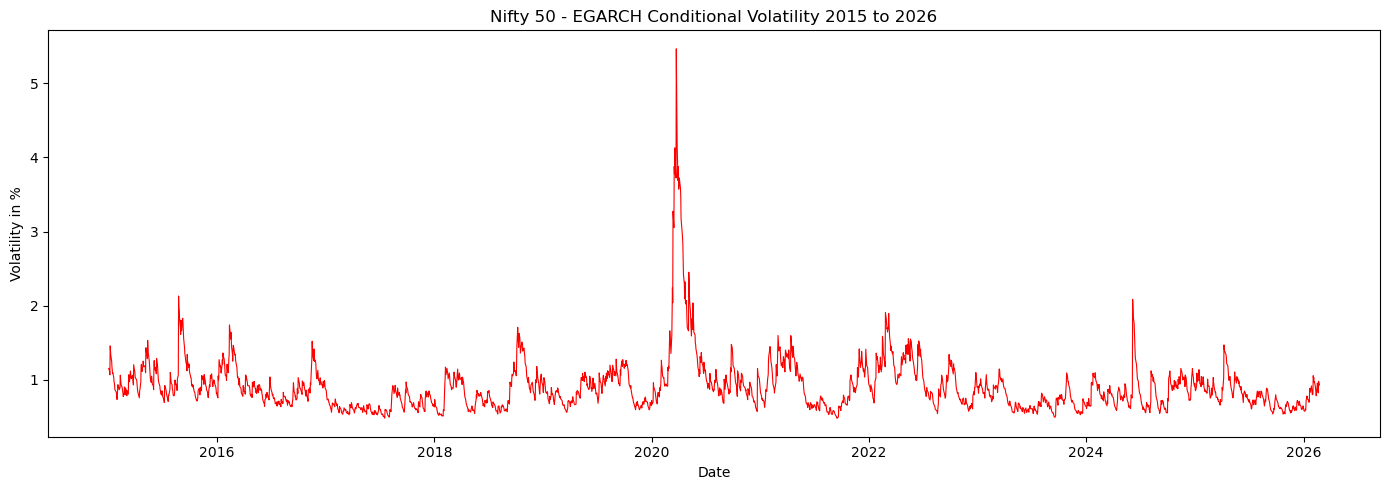

In [12]:
plt.figure(figsize=(14,5))
plt.plot(df['Date'], result.conditional_volatility, color='red', linewidth=0.8)
plt.title('Nifty 50 - EGARCH Conditional Volatility 2015 to 2026')
plt.xlabel('Date')
plt.ylabel('Volatility in %')
plt.tight_layout()
plt.show()

In [13]:
forecast = result.forecast(horizon=30, method='simulation', simulations=1000, reindex=False)

forecast_variance = forecast.variance.values[-1]
forecast_volatility = np.sqrt(forecast_variance)

import datetime
forecast_dates = pd.bdate_range(start='2026-02-24', periods=30)

forecast_df = pd.DataFrame({'Date' : forecast_dates, 'Forecast_Volatility' : forecast_volatility})

print(forecast_df)

         Date  Forecast_Volatility
0  2026-02-24             0.873858
1  2026-02-25             0.879230
2  2026-02-26             0.885188
3  2026-02-27             0.889533
4  2026-03-02             0.891340
5  2026-03-03             0.896872
6  2026-03-04             0.897613
7  2026-03-05             0.901784
8  2026-03-06             0.904645
9  2026-03-09             0.913481
10 2026-03-10             0.920071
11 2026-03-11             0.924368
12 2026-03-12             0.930741
13 2026-03-13             0.933921
14 2026-03-16             0.944230
15 2026-03-17             0.950561
16 2026-03-18             0.948415
17 2026-03-19             0.953368
18 2026-03-20             0.956091
19 2026-03-23             0.959546
20 2026-03-24             0.959859
21 2026-03-25             0.969492
22 2026-03-26             0.970258
23 2026-03-27             0.974697
24 2026-03-30             0.979062
25 2026-03-31             0.983254
26 2026-04-01             0.982236
27 2026-04-02       

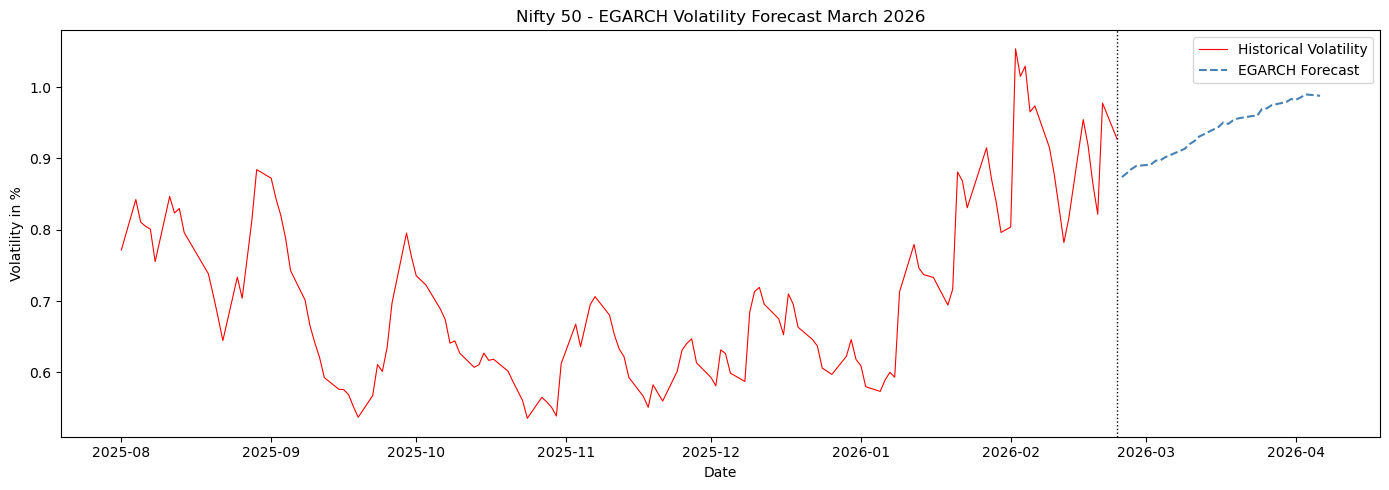

In [14]:
plt.figure(figsize=(14,5))

last_6month = df[df['Date'] >= '2025-08-01']
plt.plot(last_6month['Date'], result.conditional_volatility[-len(last_6month):],
         color='red', linewidth=0.8, label = 'Historical Volatility')

plt.plot(forecast_df['Date'], forecast_df['Forecast_Volatility'],
         color='steelblue', linewidth=1.5, linestyle='--', label='EGARCH Forecast')

plt.axvline(x=pd.Timestamp('2026-02-23'), color='black', linestyle=':', linewidth=1)

plt.title('Nifty 50 - EGARCH Volatility Forecast March 2026')
plt.xlabel('Date')
plt.ylabel('Volatility in %')
plt.legend()
plt.tight_layout()
plt.show()

In [15]:
sim_volatility = np.sqrt(forecast.simulations.variances[-1])

lower_band = np.percentile(sim_volatility, 5, axis=0)
upper_band = np.percentile(sim_volatility, 95, axis=0)
mean_forecast = np.mean(sim_volatility, axis=0)

print("Lower band day 1:", lower_band[0])
print("Mean forecast day 1:", mean_forecast[0])
print("Upper band day 1:", upper_band[0])

Lower band day 1: 0.8738580582407008
Mean forecast day 1: 0.8738580582406962
Upper band day 1: 0.8738580582407008


In [16]:
print("Lower band day 15:", lower_band[14])
print("Mean forecast day 15:", mean_forecast[14])
print("Upper band day 15:", upper_band[14])

Lower band day 15: 0.6612404547172829
Mean forecast day 15: 0.9204534850213303
Upper band day 15: 1.305981199539545


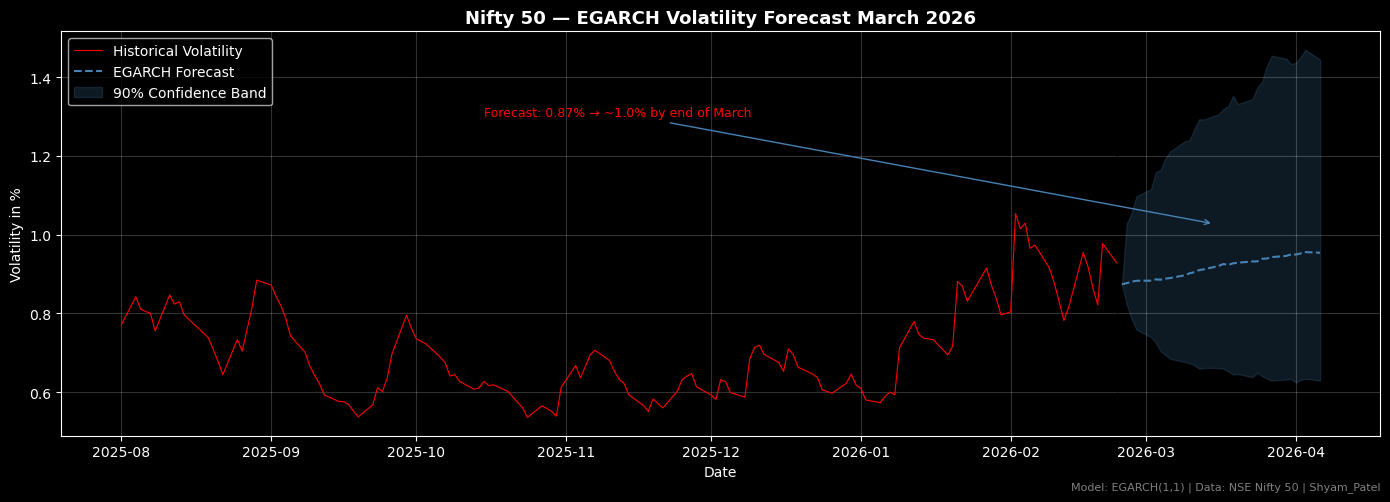

In [17]:
plt.style.use('dark_background')

fig, ax = plt.subplots(figsize=(14, 5))

last_6month = df[df['Date'] >= '2025-08-01']
ax.plot(last_6month['Date'], result.conditional_volatility[-len(last_6month):],
        color='red', linewidth=0.8, label='Historical Volatility')

ax.plot(forecast_df['Date'], mean_forecast, color='steelblue', linewidth=1.5, linestyle='--', label='EGARCH Forecast')

ax.fill_between(forecast_df['Date'], lower_band, upper_band, color='steelblue', alpha=0.2, label='90% Confidence Band')

ax.axvline(x=pd.Timestamp('2026-02-23'),color='black', linestyle=':', linewidth=1)

ax.annotate('Forecast: 0.87% → ~1.0% by end of March', xy=(pd.Timestamp('2026-03-15'), upper_band[1]),
            xytext=(pd.Timestamp('2025-10-15'), 1.3),
            arrowprops=dict(arrowstyle='->', color='steelblue'), fontsize=9, color='red')

ax.set_title('Nifty 50 — EGARCH Volatility Forecast March 2026',fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Volatility in %')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.2)

fig.text(0.99, 0.01, 'Model: EGARCH(1,1) | Data: NSE Nifty 50 | Shyam_Patel', ha='right', fontsize=8, color='gray')

plt.tight_layout()
plt.show()

# Model 2: GJR-GARCH

In [18]:
from arch import arch_model

gjr_model = arch_model(returns, mean='Constant', vol='GARCH',
    p=1,o=1,q=1,dist='normal')

gjr_result = gjr_model.fit(disp='off')
print(gjr_result.summary())

                   Constant Mean - GJR-GARCH Model Results                    
Dep. Variable:            log_returns   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                  GJR-GARCH   Log-Likelihood:               -3483.99
Distribution:                  Normal   AIC:                           6977.98
Method:            Maximum Likelihood   BIC:                           7007.59
                                        No. Observations:                 2758
Date:                Mon, Feb 23 2026   Df Residuals:                     2757
Time:                        18:58:48   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu             0.0377  1.534e-02      2.458  1.398e-02 [7.

In [19]:
gjr_forecast = gjr_result.forecast(horizon=30, reindex=False)

gjr_variance = gjr_forecast.variance.values[-1]
gjr_vol = np.sqrt(gjr_variance)

gjr_forecast_df = pd.DataFrame({'Date': forecast_dates,'Forecast_Volatility': gjr_vol})

print(gjr_forecast_df.head())

        Date  Forecast_Volatility
0 2026-02-24             0.896794
1 2026-02-25             0.897807
2 2026-02-26             0.898778
3 2026-02-27             0.899708
4 2026-03-02             0.900599


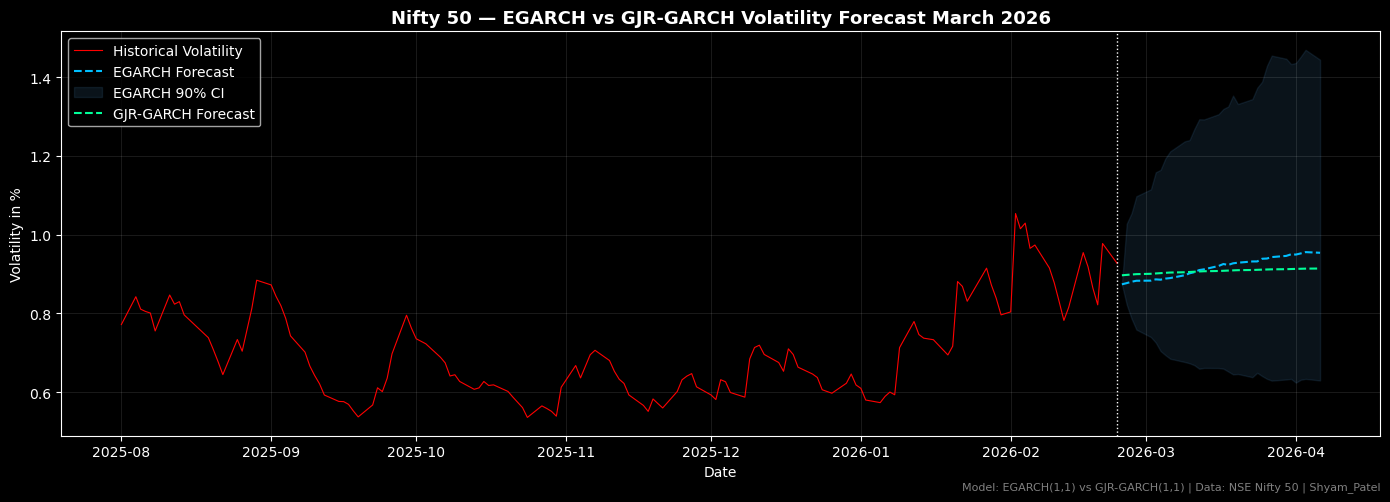

In [20]:
plt.style.use('dark_background')

fig, ax = plt.subplots(figsize=(14, 5))

last_6month = df[df['Date'] >= '2025-08-01']

ax.plot(last_6month['Date'], result.conditional_volatility[-len(last_6month):],
        color='red', linewidth=0.8, label='Historical Volatility')

ax.plot(forecast_df['Date'], mean_forecast, color='#00bfff', linewidth=1.5, linestyle='--', label='EGARCH Forecast')

ax.fill_between(forecast_df['Date'], lower_band, upper_band, color='steelblue', alpha=0.15, label='EGARCH 90% CI')

ax.plot(gjr_forecast_df['Date'], gjr_forecast_df['Forecast_Volatility'], color='#00ff99', linewidth=1.5, linestyle='--', label='GJR-GARCH Forecast')

ax.axvline(x=pd.Timestamp('2026-02-23'), color='white', linestyle=':', linewidth=1)

ax.set_title('Nifty 50 — EGARCH vs GJR-GARCH Volatility Forecast March 2026',fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Volatility in %')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.1)

fig.text(0.99, 0.01, 'Model: EGARCH(1,1) vs GJR-GARCH(1,1) | Data: NSE Nifty 50 | Shyam_Patel',
         ha='right', fontsize=8, color='gray')

plt.tight_layout()
plt.show()

## EGARCH vs GJR-GARCH — what's the difference?
#### Both models solve the same problem, GARCH treats crashes and rallies identically, which is wrong. These two fix that.
#### EGARCH works in log space. It uses a direction term (gamma) that mathematically amplifies crashes and dampens rallies. High beta means long memory — once volatility spikes, it decays slowly.
#### GJR-GARCH stays in variance space. It uses a simple switch — crash day the extra coefficient fires, rally day it stays silent. On Nifty, rally shocks contribute almost zero. Only crashes move volatility.
### Same real world story, different mechanism. GJR-GARCH wins on Nifty data by AIC and BIC — sometimes simple beats sophisticated.
